In [1]:
from langgraph.graph import StateGraph, START, MessagesState
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
model = ChatOpenAI()

In [4]:
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

In [5]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

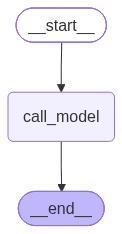

In [6]:
graph = builder.compile()
graph

In [9]:

graph.invoke({"messages": [{"role": "user", "content": "Hi! My name is Arpit."}]})

{'messages': [HumanMessage(content='Hi! My name is Arpit.', additional_kwargs={}, response_metadata={}, id='e769453a-403e-4dbd-91ba-4e081f427f5c'),
  AIMessage(content='Hello Arpit! How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 15, 'total_tokens': 26, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-E51eUkSMsY0pTqVl3ryNtfkOZ9302', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f9258-7212-7773-bea6-8e80ed274c41-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 15, 'output_tokens': 11, 'total_tokens': 26, 'input_token_details': {'audio': 0, 'ca

In [10]:
graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]})

{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='950a6f92-20e9-4676-84ba-0f56b5a8b180'),
  AIMessage(content="I'm sorry, I do not have access to that information.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 12, 'total_tokens': 25, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-E51eXdVpufdR0BuuV3uvLAieKK1UJ', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f9258-7c1d-78e0-b621-cfe5559c1fec-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 12, 'output_tokens': 13, 'total_tokens': 25, 'input_token_details': {'audio

In [17]:
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

In [18]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

In [22]:
from langgraph.checkpoint.memory import InMemorySaver
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

In [24]:
config = {"configurable": {"thread_id": "thread-1"}}
config2 = {"configurable": {"thread_id": "thread-2"}}

In [25]:
graph.invoke({"messages": [{"role": "user", "content": "Hi! My name is Arpit."}]}, config)

{'messages': [HumanMessage(content='Hi! My name is Arpit.', additional_kwargs={}, response_metadata={}, id='f367f812-05f2-4072-9885-d930987a5724'),
  AIMessage(content='Nice to meet you, Arpit! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 15, 'total_tokens': 30, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-E51mAQ8jyeVsQsn9pkGTQQQ13B1Uj', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f925f-b570-71e1-8a47-ef47ff98aa07-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 15, 'output_tokens': 15, 'total_tokens': 30, 'input_token_details': {'

In [26]:
graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]}, config)

{'messages': [HumanMessage(content='Hi! My name is Arpit.', additional_kwargs={}, response_metadata={}, id='f367f812-05f2-4072-9885-d930987a5724'),
  AIMessage(content='Nice to meet you, Arpit! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 15, 'total_tokens': 30, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-E51mAQ8jyeVsQsn9pkGTQQQ13B1Uj', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f925f-b570-71e1-8a47-ef47ff98aa07-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 15, 'output_tokens': 15, 'total_tokens': 30, 'input_token_details': {'

In [27]:
graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]}, config2)

{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='e656a6b0-6181-48db-8322-554d31658605'),
  AIMessage(content="I'm sorry, I do not have access to your personal information, so I do not know your name. Can I assist you with anything else?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 12, 'total_tokens': 42, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-E51nSGqG5aSXL7U5YsaWNp2baBjQi', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f9260-f04f-7d31-92df-6ebe81e8f7f7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1

In [ ]:
snap = graph.get_state(config)
vals = snap.values
for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content)

- HumanMessage : Hi! My name is Arpit.
- AIMessage : Nice to meet you, Arpit! How can I assist you today?
- HumanMessage : What is my name?
- AIMessage : Your name is Arpit. How can I assist you today?


In [30]:
print(snap)

StateSnapshot(values={'messages': [HumanMessage(content='Hi! My name is Arpit.', additional_kwargs={}, response_metadata={}, id='f367f812-05f2-4072-9885-d930987a5724'), AIMessage(content='Nice to meet you, Arpit! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 15, 'total_tokens': 30, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-E51mAQ8jyeVsQsn9pkGTQQQ13B1Uj', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f925f-b570-71e1-8a47-ef47ff98aa07-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 15, 'output_tokens': 15, 'total_tokens': 30, 'input